# 단어의 의미 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 시소러스
- 사람이 직접 단어의 관계 지정
    - 시대변화에 대응 안됨
    - 인건비
    - 단어의 미묘한 차이 어려움
- 유의어 그룹, 상하위 그룹
- wordnet 등

## 통계 기법
- 말뭉치 - 텍스트 집합

In [3]:
def preprocess(text):
    text = text.lower()
    text = text.replace('.', ' .')
    words = text.split(' ')

    word_to_id = {}
    id_to_word = {}
    for word in words:
        if word not in word_to_id:
            new_id = len(word_to_id)
            word_to_id[word] = new_id
            id_to_word[new_id] = word

    corpus = np.array([word_to_id[w] for w in words])

    return corpus, word_to_id, id_to_word

In [4]:
preprocess("you say goodbye and i say hello .")

(array([0, 1, 2, 3, 4, 1, 5, 6, 7]),
 {'you': 0,
  'say': 1,
  'goodbye': 2,
  'and': 3,
  'i': 4,
  'hello': 5,
  '': 6,
  '.': 7},
 {0: 'you',
  1: 'say',
  2: 'goodbye',
  3: 'and',
  4: 'i',
  5: 'hello',
  6: '',
  7: '.'})

### 분산 표현
- 단어의 의미를 정확히 표현하기 위한 벡터표현
- 분포가설 
    - 단어 자체가 아니라 맥락이 의미를 생성
    - 주변에 놓인 단어에 따라 단어의 의미 결정
- 동시발생 행렬
    - 주변에 단어가 몇번 나타나는지 집계

In [5]:
def create_co_matrix(corpus, vocab_size, window_size=1):
    corpus_size = len(corpus)
    co_matrix = np.zeros((vocab_size, vocab_size), dtype=np.int32)

    for idx, word_id in enumerate(corpus):
        for i in range(1, window_size + 1):
            left_idx = idx - i
            right_idx = idx + i

            if left_idx >= 0:
                left_word_id = corpus[left_idx]
                co_matrix[word_id, left_word_id] += 1

            if right_idx < corpus_size:
                right_word_id = corpus[right_idx]
                co_matrix[word_id, right_word_id] += 1

    return co_matrix

In [6]:
corpus, word2id, id2word = preprocess("you say goodbye and i say hello .")
co = create_co_matrix(corpus, len(word2id))
co

array([[0, 1, 0, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 1, 1, 0, 0],
       [0, 1, 0, 1, 0, 0, 0, 0],
       [0, 0, 1, 0, 1, 0, 0, 0],
       [0, 1, 0, 1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 0, 0, 1, 0]], dtype=int32)

### 벡터 유사도
- 코사인 유사도 $$similarity(u, v) = \frac{u\cdot v}{|u||v|}$$

In [7]:
def cos_sim(x, y, eps=1e-8): # 0 벡터 방지
    nx = x / (np.sqrt(np.sum(x ** 2)) + eps)
    ny = y / (np.sqrt(np.sum(y ** 2)) + eps)
    return np.dot(nx, ny)


In [8]:
f = lambda x: co[word2id[x]]
cos_sim(f("i"), f("you"))

np.float64(0.7071067691154799)

In [9]:

def most_similar(query, word_to_id, id_to_word, word_matrix, top=5):
    if query not in word_to_id:
        print('%s(을)를 찾을 수 없습니다.' % query)
        return

    print('\n[query] ' + query)
    query_id = word_to_id[query]
    query_vec = word_matrix[query_id]

    vocab_size = len(id_to_word)

    similarity = np.zeros(vocab_size)
    for i in range(vocab_size):
        similarity[i] = cos_sim(word_matrix[i], query_vec)

    count = 0
    for i in (-1 * similarity).argsort():
        if id_to_word[i] == query:
            continue
        print(' %s: %s' % (id_to_word[i], similarity[i]))

        count += 1
        if count >= top:
            return

In [10]:
most_similar("you", word2id, id2word, co, 5)


[query] you
 goodbye: 0.7071067691154799
 hello: 0.7071067691154799
 i: 0.7071067691154799
 and: 0.0
 say: 0.0


### 점별 상호 정보량
- 공동확률과 독립 가정 공동확률의 로그비
- PMI $$PMI(x, y) = \log_2\frac{P(x, y)}{P(x)P(y)} \approx \log_2\frac{C(x, y)}{C(x)C(y)}$$
- 양의 상호정보량 - 음일 때는 무시

In [11]:
def ppmi(C, verbose=False, eps = 1e-8):
    M = np.zeros_like(C, dtype=np.float32)
    N = np.sum(C)
    S = np.sum(C, axis=0)
    total = C.shape[0] * C.shape[1]
    cnt = 0

    for i in range(C.shape[0]):
        for j in range(C.shape[1]):
            pmi = np.log2(C[i, j] * N / (S[j]*S[i]) + eps)
            M[i, j] = max(0, pmi)

            if verbose:
                cnt += 1
                if cnt % (total//100) == 0:
                    print('%.1f%% 완료' % (100*cnt/total))
    return M


In [12]:
W = ppmi(co)
W

array([[0., 2., 0., 0., 0., 0., 0., 0.],
       [2., 0., 1., 0., 1., 1., 0., 0.],
       [0., 1., 0., 2., 0., 0., 0., 0.],
       [0., 0., 2., 0., 2., 0., 0., 0.],
       [0., 1., 0., 2., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 2., 0.],
       [0., 0., 0., 0., 0., 2., 0., 3.],
       [0., 0., 0., 0., 0., 0., 3., 0.]], dtype=float32)

### SVD
- 행렬을 입력 방향 정렬, 축별 스케일링, 출력 방향 정렬로 분해
- $$A = U\Sigma V^T$$
    - $U\in \mathbb R^{m\times m}$ : 왼쪽 특이 행렬, 회전
    - $\Sigma \in \mathbb R^{m\times n}$ : 특이값 대각성분 축방향 스케일링
    - $V\in \mathbb R^{n\times n}$ : 오른쪽 특이벡터 열벡터, 회전
- 특이값
    - 특이벡터 방향 스케일 크기 
    - 해당 방향 중요도 높음
    - 상위 정보만 가지고 근사 가능

In [13]:
corpus, word2id, id2word = preprocess("you say goodbye and i say hello.")
co = create_co_matrix(corpus, len(word2id))
co
W = ppmi(co)

U, S, V = np.linalg.svd(W)

np.set_printoptions(precision=3)
print(co[0])
print(W[0])
print(U[0])

[0 1 0 0 0 0 0]
[0.    1.807 0.    0.    0.    0.    0.   ]
[-1.110e-16  3.409e-01 -4.163e-16 -1.205e-01 -1.110e-16 -9.323e-01
 -1.086e-16]


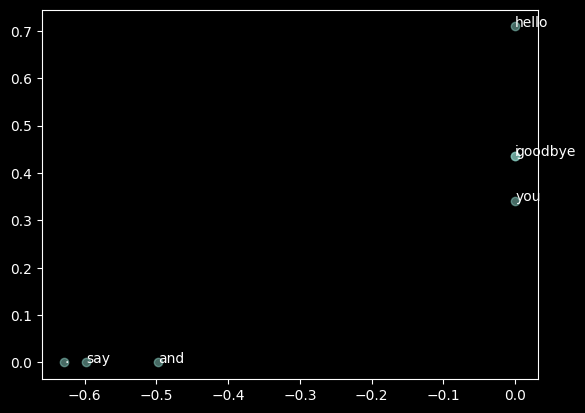

In [14]:
for word, word_id in word2id.items():
    plt.annotate(word, (U[word_id, 0], U[word_id, 1]))
plt.scatter(U[:,0], U[:,1], alpha=0.5)
plt.show()


# PTB

In [15]:
from datasets import ptb

corpus, word_to_id, id_to_word = ptb.load_data('train')

print('말뭉치 크기:', len(corpus))
print('corpus[:30]:', corpus[:30])
print()
print('id_to_word[0]:', id_to_word[0])
print('id_to_word[1]:', id_to_word[1])
print('id_to_word[2]:', id_to_word[2])
print()
print("word_to_id['car']:", word_to_id['car'])
print("word_to_id['happy']:", word_to_id['happy'])
print("word_to_id['lexus']:", word_to_id['lexus'])


말뭉치 크기: 929589
corpus[:30]: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

id_to_word[0]: aer
id_to_word[1]: banknote
id_to_word[2]: berlitz

word_to_id['car']: 3856
word_to_id['happy']: 4428
word_to_id['lexus']: 7426


In [16]:
window_size = 2
wordvec_size = 100

corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)
print('동시발생 수 계산 ...')
C = create_co_matrix(corpus, vocab_size, window_size)
print('PPMI 계산 ...')
W = ppmi(C, verbose=True)

print('calculating SVD ...')
try:
    from sklearn.utils.extmath import randomized_svd
    U, S, V = randomized_svd(W, n_components=wordvec_size, n_iter=5,
                             random_state=None)
except ImportError:
    U, S, V = np.linalg.svd(W)

word_vecs = U[:, :wordvec_size]

querys = ['you', 'year', 'car', 'toyota']
for query in querys:
    most_similar(query, word_to_id, id_to_word, word_vecs, top=5)


동시발생 수 계산 ...
PPMI 계산 ...
1.0% 완료
2.0% 완료
3.0% 완료
4.0% 완료
5.0% 완료
6.0% 완료
7.0% 완료
8.0% 완료
9.0% 완료
10.0% 완료
11.0% 완료
12.0% 완료
13.0% 완료
14.0% 완료
15.0% 완료
16.0% 완료
17.0% 완료
18.0% 완료
19.0% 완료
20.0% 완료
21.0% 완료
22.0% 완료
23.0% 완료
24.0% 완료
25.0% 완료
26.0% 완료
27.0% 완료
28.0% 완료
29.0% 완료
30.0% 완료
31.0% 완료
32.0% 완료
33.0% 완료
34.0% 완료
35.0% 완료
36.0% 완료
37.0% 완료
38.0% 완료
39.0% 완료
40.0% 완료
41.0% 완료
42.0% 완료
43.0% 완료
44.0% 완료
45.0% 완료
46.0% 완료
47.0% 완료
48.0% 완료
49.0% 완료
50.0% 완료
51.0% 완료
52.0% 완료
53.0% 완료
54.0% 완료
55.0% 완료
56.0% 완료
57.0% 완료
58.0% 완료
59.0% 완료
60.0% 완료
61.0% 완료
62.0% 완료
63.0% 완료
64.0% 완료
65.0% 완료
66.0% 완료
67.0% 완료
68.0% 완료
69.0% 완료
70.0% 완료
71.0% 완료
72.0% 완료
73.0% 완료
74.0% 완료
75.0% 완료
76.0% 완료
77.0% 완료
78.0% 완료
79.0% 완료
80.0% 완료
81.0% 완료
82.0% 완료
83.0% 완료
84.0% 완료
85.0% 완료
86.0% 완료
87.0% 완료
88.0% 완료
89.0% 완료
90.0% 완료
91.0% 완료
92.0% 완료
93.0% 완료
94.0% 완료
95.0% 완료
96.0% 완료
97.0% 완료
98.0% 완료
99.0% 완료
100.0% 완료
calculating SVD ...

[query] you
 we: 0.6454493999481201
 i: 0.6448832750320435
 a

## 문제점
- 거대 행렬에 대한 svd 적용의 어려움 $O(n^3)$
- 